In [182]:
# importing
from bs4 import BeautifulSoup
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
url = "https://www.coingecko.com/"

In [76]:
# requests

response = requests.get(url)

In [77]:
response

<Response [200]>

In [78]:
soup = BeautifulSoup(response.content,"html.parser")

In [79]:
soup

<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<link href="/favicon.ico" rel="shortcut icon"/>
<link href="/OpensearchDescription.xml" rel="search" type="application/opensearchdescription+xml">
<title>Cryptocurrency Prices, Charts, and Crypto Market Cap | CoinGecko</title>
<meta content="View top cryptocurrency prices live, crypto charts, market cap, and trading volume. Discover today’s new and trending coins, top crypto gainers and losers in the market." name="description">
<!-- OptanonConsentNoticeStart -->
<script charset="UTF-8" data-document-language="true" data-domain-script="49e8a847-f2c7-4b58-a340-caf0924064fe" defer="" src="https://cdn-apac.onetrust.com/scripttemplates/otSDKStub.js" type="text/javascript"></script>
<script type="text/javascript">
  const STRICT_COOKIE = "C0001";
  const PERF_COOKIE = "C0002";
  const FUNC_COOKIE = "C0

In [80]:
results = soup.find("tbody")
rows = results.find_all("tr")

In [81]:
len(rows)

100

In [82]:
# Target necessary data
# 1.coin
# 2.price
#3.change_1h
#4.change_24h
#5.change_7d
#6.volume
#7.market_cap


In [83]:
# 1. coin

In [84]:
text = rows[0].find('a',{'class':'tw-flex tw-items-center tw-w-full'}).get_text()
clean = " ".join(text.split())
print(clean)





Bitcoin BTC


In [85]:
cols = rows[0].find_all('td', {'class':'tw-text-end'})
for i, col in enumerate(rows):
    print(i, col.text)

0 
 


1
 



  
                      Bitcoin
                      
  BTC

 




      Buy
    










 


$68,668.45
0.1%
0.7%
1.6%
2.2%
$43,529,335,740
$1,373,852,947,115
$1,373,855,281,206
1.0
 



1 
 


2
 



  
                      Ethereum
                      
  ETH

 




      Buy
    










 


$2,102.81
0.1%
1.6%
2.0%
8.0%
$16,750,098,713
$253,713,019,001
$253,713,019,001
1.0
 



2 
 


3
 



  
                      Tether
                      
  USDT

 


$0.9999
0.0%
0.0%
0.1%
0.0%
$66,158,191,388
$184,139,694,825
$189,606,284,795
0.97
 



3 
 


4
 



  
                      BNB
                      
  BNB

 




      Buy
    










 


$598.69
0.0%
0.8%
2.3%
3.2%
$707,072,295
$81,612,285,650
$81,612,283,574
1.0
 



4 
 


5
 



  
                      XRP
                      
  XRP

 




      Buy
    










 


$1.31
0.3%
2.0%
0.7%
3.0%
$1,548,196,308
$80,574,018,830
$131,197,441,877
0.61
 



5 
 


6
 



  
                      US

In [86]:
# price

In [87]:
price = cols[0].text.strip()

In [88]:
price

'$68,668.45'

In [89]:
# change_1h

In [90]:
change_1h = cols[1].text.strip()


In [91]:
change_1h

'0.1%'

In [92]:
# change_24h

In [93]:
change_24h = cols[2].text.strip()


In [94]:
change_24h

'0.7%'

In [95]:
# change_7d

In [96]:
change_7d = cols[3].text.strip()

In [97]:
change_7d

'1.6%'

In [98]:
# volume

In [99]:

volume = cols[5].text.strip()

In [100]:
volume

'$43,529,335,740'

In [101]:
# market_cap

In [102]:
market_cap = cols[6].text.strip()

In [103]:
market_cap

'$1,373,852,947,115'

In [104]:
# single page collection

In [105]:
name = []
price = []
change_1h = []
change_24h = []
change_7d = []
volume = []
market_cap = []

for row in rows:
    
    # NAME
    try:
        text = row.find('a', {'class':'tw-flex tw-items-center tw-w-full'}).get_text()
        clean = " ".join(text.split())
        name.append(clean)
    except:
        name.append('n/a')

    # PRICE
    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        price.append(cols[0].text.strip())
    except:
        price.append('n/a')

    # change_1h

    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        change_1h.append(cols[1].text.strip())
    except:
        change_1h.append('n/a')

    # change_24h
    
    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        change_24h.append(cols[2].text.strip())
    except:
        change_24h.append('n/a')

    # change_7d

    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        change_7d.append(cols[3].text.strip())
    except:
        change_7d.append('n/a')

    # volume

    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        volume.append(cols[5].text.strip())
    except:
        volume.append('n/a')

    # market_cap

    try:
        cols = row.find_all('td', {'class':'tw-text-end'})
        market_cap.append(cols[6].text.strip())
    except:
        market_cap.append('n/a')
    
    
    

In [106]:
crypto_df = pd.DataFrame({'Coin': name,'Price':price,'Change_1h':change_1h,'Change_24h':change_24h,'Change_7d':change_7d,'Volume':volume,'Market_cap':market_cap})

In [107]:
crypto_df.to_excel("single_page.xlsx", index=False, engine="openpyxl")

In [108]:
import os
print(os.getcwd())

C:\Users\sravy


In [109]:
crypto_df

,Coin,Price,Change_1h,Change_24h,Change_7d,Volume,Market_cap
0,Bitcoin BTC,"$68,668.45",0.1%,0.7%,1.6%,"$43,529,335,740","$1,373,852,947,115"
1,Ethereum ETH,"$2,102.81",0.1%,1.6%,2.0%,"$16,750,098,713","$253,713,019,001"
2,Tether USDT,$0.9999,0.0%,0.0%,0.1%,"$66,158,191,388","$184,139,694,825"
3,BNB BNB,$598.69,0.0%,0.8%,2.3%,"$707,072,295","$81,612,285,650"
4,XRP XRP,$1.31,0.3%,2.0%,0.7%,"$1,548,196,308","$80,574,018,830"
...,...,...,...,...,...,...,...
95,Artificial Superintelligence Alliance FET,$0.2332,1.3%,1.4%,1.5%,"$93,576,268","$526,411,979"
96,Bonk BONK,$0.055634,0.2%,1.7%,3.5%,"$48,928,145","$495,890,681"
97,TrueUSD TUSD,$0.9988,0.0%,0.0%,0.1%,"$8,751,524","$493,934,032"
98,A7A5 A7A5,$0.01237,0.4%,0.8%,0.5%,"$1,838.60","$484,883,087"


In [110]:
# multiple page collectio

In [134]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# lists
name = []
price = []
change_1h = []
change_24h = []
change_7d = []
volume = []
market_cap = []

headers = {"User-Agent": "Mozilla/5.0"}

# loop through pages
for i in range(1, 167):   # change 6 → number of pages you want
    
    print("Scraping page:", i)
    
    url = f"https://www.coingecko.com/?page={i}"
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    
    results = soup.find("tbody")
    
    if results is None:
        print("Skipping page:", i)
        continue

    rows = results.find_all("tr")

    for row in rows:
        cols = row.find_all("td")

        # NAME
        try:
            text = row.find('a', {'class': 'tw-flex tw-items-center tw-w-full'}).get_text()
            name.append(" ".join(text.split()))
        except:
            name.append('n/a')

        # PRICE
        try:
            price.append(cols[4].text.strip())
        except:
            price.append('n/a')

        # 1H
        try:
            change_1h.append(cols[5].text.strip())
        except:
            change_1h.append('n/a')

        # 24H
        try:
            change_24h.append(cols[5].text.strip())
        except:
            change_24h.append('n/a')

        # 7D
        try:
            change_7d.append(cols[7].text.strip())
        except:
            change_7d.append('n/a')

        # VOLUME
        try:
            volume.append(cols[9].text.strip())
        except:
            volume.append('n/a')

        # MARKET CAP
        try:
            market_cap.append(cols[10].text.strip())
        except:
            market_cap.append('n/a')


Scraping page: 1
Scraping page: 2
Scraping page: 3
Scraping page: 4
Scraping page: 5
Scraping page: 6
Scraping page: 7
Scraping page: 8
Scraping page: 9
Scraping page: 10
Scraping page: 11
Scraping page: 12
Scraping page: 13
Scraping page: 14
Scraping page: 15
Scraping page: 16
Scraping page: 17
Scraping page: 18
Scraping page: 19
Scraping page: 20
Scraping page: 21
Scraping page: 22
Scraping page: 23
Scraping page: 24
Scraping page: 25
Scraping page: 26
Scraping page: 27
Scraping page: 28
Scraping page: 29
Scraping page: 30
Scraping page: 31
Scraping page: 32
Scraping page: 33
Scraping page: 34
Scraping page: 35
Scraping page: 36
Scraping page: 37
Scraping page: 38
Scraping page: 39
Scraping page: 40
Scraping page: 41
Scraping page: 42
Scraping page: 43
Scraping page: 44
Scraping page: 45
Scraping page: 46
Scraping page: 47
Scraping page: 48
Scraping page: 49
Scraping page: 50
Scraping page: 51
Scraping page: 52
Scraping page: 53
Scraping page: 54
Scraping page: 55
Scraping page: 56
S

import requests
from bs4 import BeautifulSoup
import pandas as pd

# lists
name = []
price = []
change_1h = []
change_24h = []
change_7d = []
volume = []
market_cap = []

headers = {"User-Agent": "Mozilla/5.0"}

# loop through pages
for i in range(1, 167):   # change 6 → number of pages you want
    
    print("Scraping page:", i)
    
    url = f"https://www.coingecko.com/?page={i}"
    
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.content, "html.parser")
    
    results = soup.find("tbody")
    
    if results is None:
        print("Skipping page:", i)
        continue

    rows = results.find_all("tr")

    for row in rows:
        cols = row.find_all("td")

        # NAME
        try:
            text = row.find('a', {'class': 'tw-flex tw-items-center tw-w-full'}).get_text()
            name.append(" ".join(text.split()))
        except:
            name.append('n/a')

        # PRICE
    try:
        price_cell = row.find("td", {"class": "td-price"})
        price.append(price_cell.text.strip() if price_cell else "n/a")
    except:
        price.append("n/a")

# 1H CHANGE
    try:
        change_1h_cell = row.find("td", {"class": "td-change1h"})
        change_1h.append(change_1h_cell.text.strip() if change_1h_cell else "n/a")
    except:
        change_1h.append("n/a")

# 24H CHANGE
    try:
        change_24h_cell = row.find("td", {"class": "td-change24h"})
        change_24h.append(change_24h_cell.text.strip() if change_24h_cell else "n/a")
    except:
        change_24h.append("n/a")

# 7D CHANGE
    try:
        change_7d_cell = row.find("td", {"class": "td-change7d"})
        change_7d.append(change_7d_cell.text.strip() if change_7d_cell else "n/a")
    except:
        change_7d.append("n/a")

# VOLUME
    try:
        volume_cell = row.find("td", {"class": "td-liquidity_score"})
        volume.append(volume_cell.text.strip() if volume_cell else "n/a")
    except:
        volume.append("n/a")

# MARKET CAP
    try:
        market_cap_cell = row.find("td", {"class": "td-market_cap"})
        market_cap.append(market_cap_cell.text.strip() if market_cap_cell else "n/a")
    except:
        market_cap.append("n/a")

In [135]:
len(price)

16369

In [136]:
# create dataframe
crypto_df = pd.DataFrame({
    "Name": name,
    "Price": price,
    "1h %": change_1h,
    "24h %": change_24h,
    "7d %": change_7d,
    "Volume": volume,
    "Market Cap": market_cap
})


In [137]:
crypto_df

,Name,Price,1h %,24h %,7d %,Volume,Market Cap
0,Bitcoin BTC,"$68,924.38",0.4%,0.4%,2.2%,"$41,041,470,269","$1,379,293,273,579"
1,Ethereum ETH,"$2,114.57",0.6%,0.6%,3.0%,"$15,884,040,462","$254,974,685,930"
2,Tether USDT,$1.00,0.0%,0.0%,0.1%,"$63,675,552,860","$184,156,404,964"
3,BNB BNB,$602.01,0.6%,0.6%,1.6%,"$719,291,845","$82,018,438,377"
4,XRP XRP,$1.32,0.4%,0.4%,0.0%,"$1,546,771,242","$80,918,259,193"
...,...,...,...,...,...,...,...
16364,Eaton Corporation plc xStock ETNX,-,-,-,-,-,-
16365,Nest USDC PayFi Lending Vault NAXI,-,-,-,-,-,-
16366,CHIP CHIP,-,-,-,-,-,-
16367,DXLYN DXLYN,-,-,-,-,-,-


In [138]:
#EDA

In [139]:
import pandas as pd
crypto_df.to_csv("cryptocurrencies_multipage.csv")

In [140]:
df=pd.read_csv("cryptocurrencies_multipage.csv")

In [141]:
# DATA CLEANING
df.shape

(16369, 8)

In [142]:
df.columns

Index(['Unnamed: 0', 'Name', 'Price', '1h %', '24h %', '7d %', 'Volume',
       'Market Cap'],
      dtype='object')

In [143]:
df.dtypes

Unnamed: 0     int64
Name          object
Price         object
1h %          object
24h %         object
7d %          object
Volume        object
Market Cap    object
dtype: object

In [185]:
df["Price"]=df["Price"].astype(str)
df['Price'] = df['Price'].str.replace("$", "", regex=False)
df['Price'] = df['Price'].str.rstrip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').astype('float64')

In [186]:
df["1h %"]=df["1h %"].astype(str)
df['1h %'] = df['1h %'].str.replace("%", "", regex=False)
df['1h %'] = df['1h %'].str.strip()
df['1h %'] = pd.to_numeric(df['1h %'], errors='coerce').astype('float32')

In [187]:
df["24h %"]=df["24h %"].astype(str)
df['24h %'] = df['24h %'].str.replace("%", "", regex=False)
df['24h %'] = df['24h %'].str.strip()
df['24h %'] = pd.to_numeric(df['24h %'], errors='coerce').astype('float32')

In [188]:
df["7d %"]=df["7d %"].astype(str)
df['7d %'] = df['7d %'].str.replace("%", "", regex=False)
df['7d %'] = df['7d %'].str.strip()
df['7d %'] = pd.to_numeric(df['7d %'], errors='coerce').astype('float32')

In [189]:
df["Volume"]=df["Volume"].astype(str)
df['Volume'] = df['Volume'].str.replace("$", "", regex=False)
df['Volume'] = df['Volume'].str.strip()
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce').astype('float64')

In [190]:
df["Market Cap"]=df["Market Cap"].astype(str)
df['Market Cap'] = df['Market Cap'].str.replace("$", "", regex=False)
df['Market Cap'] = df['Market Cap'].str.strip()
df['Market Cap'] = pd.to_numeric(df['Market Cap'], errors='coerce').astype('float64')

In [191]:
df.dtypes

Unnamed: 0      int64
Name           object
Price         float64
1h %          float32
24h %         float32
7d %          float32
Volume        float64
Market Cap    float64
dtype: object

In [154]:
print("Missing values info:/n",df.isnull().sum())

Missing values info:/n Unnamed: 0        0
Name              0
Price          1108
1h %           6868
24h %          6868
7d %           6130
Volume         6470
Market Cap    16284
dtype: int64


In [155]:
q1=df['Price'].quantile(0.25)
q3=df['Price'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [156]:
outliers=df[(df['Price']<lower)|(df['Price']>upper)]
print('Outliers:',len(outliers['Price']))

Outliers: 2092


In [157]:
df['Price'].fillna(df['Price'].median(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\3727517126.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].median(),inplace=True)


In [158]:
df.isnull().sum()

Unnamed: 0        0
Name              0
Price             0
1h %           6868
24h %          6868
7d %           6130
Volume         6470
Market Cap    16284
dtype: int64

In [159]:
q1=df['1h %'].quantile(0.25)
q3=df['1h %'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [160]:
outliers=df[(df['1h %']<lower)|(df['1h %']>upper)]
print('Outliers:',len(outliers['1h %']))

Outliers: 993


In [161]:
df['1h %'].fillna(df['1h %'].median(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\2104996235.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['1h %'].fillna(df['1h %'].median(),inplace=True)


In [162]:
q1=df['24h %'].quantile(0.25)
q3=df['24h %'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [163]:
outliers=df[(df['24h %']<lower)|(df['24h %']>upper)]
print('Outliers:',len(outliers['24h %']))

Outliers: 993


In [164]:
df['24h %'].fillna(df['24h %'].median(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\625040612.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['24h %'].fillna(df['24h %'].median(),inplace=True)


In [165]:
q1=df['7d %'].quantile(0.25)
q3=df['7d %'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [166]:
outliers=df[(df['7d %']<lower)|(df['1h %']>upper)]
print('Outliers:',len(outliers['1h %']))

Outliers: 18


In [167]:
df['7d %'].fillna(df['7d %'].median(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\2583612420.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['7d %'].fillna(df['7d %'].median(),inplace=True)


In [168]:
q1=df['Volume'].quantile(0.25)
q3=df['Volume'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [169]:
outliers=df[(df['Volume']<lower)|(df['Volume']>upper)]
print('Outliers:',len(outliers['Volume']))

Outliers: 1378


In [170]:
df['Volume'].fillna(df['Volume'].median(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\2521834689.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Volume'].fillna(df['Volume'].median(),inplace=True)


In [171]:
q1=df['Market Cap'].quantile(0.25)
q3=df['Market Cap'].quantile(0.75)
iqr=q3-q1
upper=q3+1.5*iqr
lower=q1-1.5*iqr

In [172]:
outliers=df[(df['Market Cap']<lower)|(df['Market Cap']>upper)]
print('Outliers:',len(outliers['Market Cap']))

Outliers: 0


In [173]:
df['Market Cap'].fillna(df['Market Cap'].mean(),inplace=True)

C:\Users\sravy\AppData\Local\Temp\ipykernel_2280\3183881550.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Market Cap'].fillna(df['Market Cap'].mean(),inplace=True)


In [174]:
df.isnull().sum()

Unnamed: 0    0
Name          0
Price         0
1h %          0
24h %         0
7d %          0
Volume        0
Market Cap    0
dtype: int64

In [175]:
df.duplicated().sum()

np.int64(0)

In [176]:
#  ANALYSIS


In [177]:
top_24h = df.sort_values('24h %', ascending=False).head(10)
top_7d = df.sort_values('7d %', ascending=False).head(10)

In [178]:
top_24h

,Unnamed: 0,Name,Price,1h %,24h %,7d %,Volume,Market Cap
2282,2282,Woonkly WOOP,0.002,4684.0,4684.0,4053.5,0.00002,424.742013
3246,3246,GCoin GC,0.006956,189.699997,189.699997,197.100006,183.11,424.742013
5004,5004,OSOL OSOL,0.000165,156.600006,156.600006,180.800003,125.9,424.742013
1494,1494,Neutrino Index Token XTN,0.07189,146.399994,146.399994,3.5,15.52,424.742013
6261,6261,TROLLI CTO TROLLICTO,0.00008,119.400002,119.400002,629.5,15.52,424.742013
6881,6881,JUST Stablecoin USDJ,0.01999,95.800003,95.800003,96.199997,222.52,424.742013
5920,5920,Bingus The Cat BINGUS,0.000088,88.599998,88.599998,88.300003,1.3,424.742013
14111,14111,9mm 9MM,0.000489,87.300003,87.300003,87.599998,23.64,424.742013
6101,6101,Shika-yan SHIKA-YAN,0.000075,52.599998,52.599998,4.3,15.52,424.742013
13710,13710,Shanum SHAN,0.000176,50.099998,50.099998,49.5,99.95,424.742013


In [179]:
top_7d

,Unnamed: 0,Name,Price,1h %,24h %,7d %,Volume,Market Cap
2508,2508,CeluvPlay CELB,0.00632,0.2,0.2,127311.296875,15.52,424.742013
13316,13316,BitTorrent [OLD] BTTOLD,0.000343,0.0,0.0,103500.0,934.71,424.742013
13452,13452,New World Order STATE,0.091879,0.5,0.5,7478.700195,323.84,424.742013
1336,1336,Beta Finance BETA,0.007567,0.8,0.8,5757.600098,878.75,424.742013
3537,3537,Neos.ai NEOS,0.005399,2.0,2.0,5406.0,15.52,424.742013
14272,14272,MAI (Fantom) MIMATIC,1.06,0.0,0.0,4710.0,13.78,424.742013
2282,2282,Woonkly WOOP,0.002,4684.0,4684.0,4053.5,0.00002,424.742013
12492,12492,Dotcom Y2K,0.000522,0.5,0.5,2308.0,533.16,0.06522
2252,2252,Titan Blaze BLAZE,1.54,0.0,0.0,2134.899902,15.52,424.742013
3815,3815,E4C E4C,0.002036,0.2,0.2,2070.600098,56.81,424.742013


<Axes: xlabel='Market Cap', ylabel='Volume'>

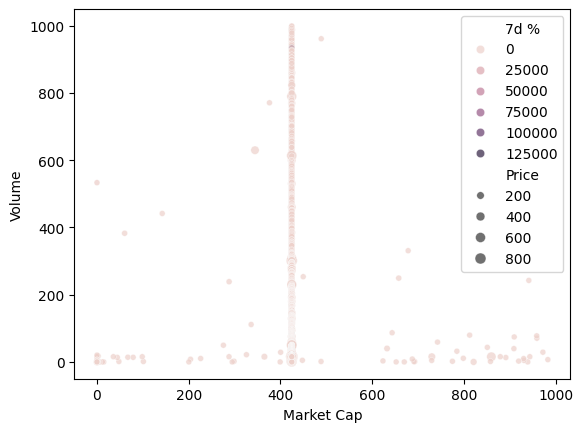

In [192]:
# Marketcap vs Volume
sns.scatterplot(data=df, x='Market Cap', y='Volume', size='Price', hue='7d %', alpha=0.7)

In [193]:
# Volatility Analysis
df['volatility'] = df[['1h %','24h %','7d %']].std(axis=1)
df.sort_values('volatility', ascending=False).head(10)

,Unnamed: 0,Name,Price,1h %,24h %,7d %,Volume,Market Cap,volatility
2508,2508,CeluvPlay CELB,0.006320,0.2,0.2,127311.296875,15.52,424.74200,73503.093750
13316,13316,BitTorrent [OLD] BTTOLD,0.000343,0.0,0.0,103500.000000,934.71,424.74200,59755.753906
13452,13452,New World Order STATE,0.091879,0.5,0.5,7478.700195,323.84,424.74200,4317.541016
1336,1336,Beta Finance BETA,0.007567,0.8,0.8,5757.600098,878.75,424.74200,3323.690186
3537,3537,Neos.ai NEOS,0.005399,2.0,2.0,5406.000000,15.52,424.74200,3120.000732
14272,14272,MAI (Fantom) MIMATIC,1.060000,0.0,0.0,4710.000000,13.78,424.74200,2719.319824
12492,12492,Dotcom Y2K,0.000522,0.5,0.5,2308.000000,533.16,0.06522,1332.235718
2252,2252,Titan Blaze BLAZE,1.540000,0.0,0.0,2134.899902,15.52,424.74200,1232.585083
3815,3815,E4C E4C,0.002036,0.2,0.2,2070.600098,56.81,424.74200,1195.346069
10574,10574,NFT Stars NFTS,0.004787,0.5,0.5,1707.000000,10.12,424.74200,985.248230


<Axes: >

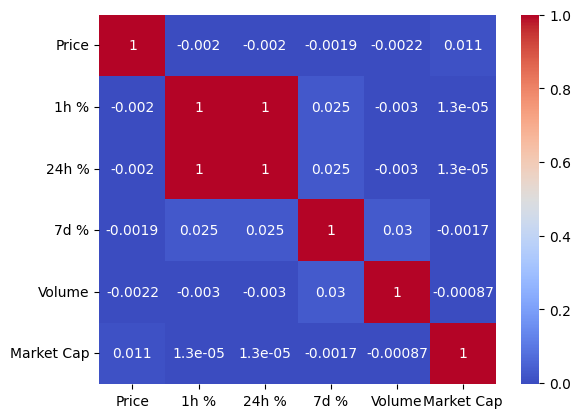

In [194]:
# Correlation analysis
corr = df[['Price','1h %','24h %','7d %','Volume','Market Cap']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='Price', ylabel='Count'>

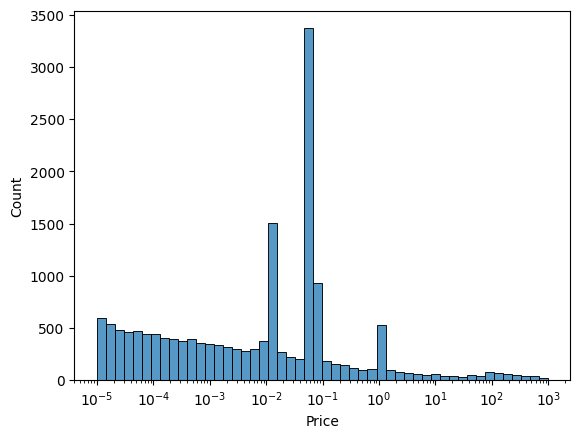

In [195]:
# price distribution
import seaborn as sns
sns.histplot(df['Price'], bins=50, log_scale=True)


In [196]:
# Market Dominance
df['market_share'] = df['Market Cap'] / df['Market Cap'].sum() * 100
df.sort_values('market_share', ascending=False).head(10)

,Unnamed: 0,Name,Price,1h %,24h %,7d %,Volume,Market Cap,volatility,market_share
12410,12410,XPowermine.com APOW [OLD] APOW,0.001086,0.6,0.6,1.6,6.90,983.17,0.577350,0.014141
12411,12411,EVERY EVERY,0.067423,0.5,0.5,4.3,28.90,972.35,2.193931,0.013985
12412,12412,US Diamond Reserve USDR,0.069376,0.5,0.5,4.3,70.45,959.22,2.193931,0.013797
12413,12413,XBANANA XBANANA,0.069973,0.5,0.5,4.3,77.54,958.84,2.193931,0.013791
12414,12414,FalconsInu FALCON,0.052360,0.5,0.5,4.3,15.52,943.83,2.193931,0.013575
12415,12415,Nemesis Downfall ND,0.075513,0.5,0.5,4.3,242.36,941.69,2.193931,0.013544
12416,12416,Re7 FRAX RE7FRAX,1.020000,0.0,0.0,0.2,0.00,939.28,0.115470,0.013510
12417,12417,Fefe FEFE,0.069314,0.5,0.5,4.3,4.60,931.03,2.193931,0.013391
12418,12418,PULSE PULSE,0.054341,0.5,0.5,4.3,9.93,930.44,2.193931,0.013383
12419,12419,The Odor ODOR,0.055780,0.5,0.5,4.3,2.45,919.48,2.193931,0.013225


In [197]:
# Liquidity Analysis
df['liquidity_ratio'] = df['Volume'] / df['Market Cap']
df.sort_values('liquidity_ratio', ascending=False).head(10)

,Unnamed: 0,Name,Price,1h %,24h %,7d %,Volume,Market Cap,volatility,market_share,liquidity_ratio
12490,12490,RocketSloth RSLT,0.052284,0.5,0.5,4.3,5.17,0.000042,2.193931,6.059602e-10,122715.404700
12492,12492,Dotcom Y2K,0.000522,0.5,0.5,2308.0,533.16,0.065220,1332.235718,9.380661e-07,8174.793008
12489,12489,EtherDoge EDOGE,0.014398,0.5,0.5,3.7,1.58,0.000398,1.847521,5.718722e-09,3973.843058
12488,12488,Hasbulla Game HASBULL,0.056262,0.5,0.5,4.3,2.66,0.006262,2.193931,9.006700e-08,424.784414
12487,12487,Ooki OOKI,0.011517,0.5,0.5,6.1,6.45,0.046270,3.233161,6.655063e-07,139.399179
12486,12486,CAT INU CAT,0.013514,0.5,0.5,4.3,20.29,0.159200,2.193931,2.289790e-06,127.449749
12485,12485,Brett ETH BRETT,0.001906,0.3,0.3,16.9,15.52,0.190600,9.584015,2.741420e-06,81.427072
12481,12481,FLock OFF SN96,0.655600,0.5,0.5,4.3,15.52,0.394200,2.193931,5.669820e-06,39.370878
12491,12491,The Jupiter Cat JUPCAT,0.052921,0.5,0.5,4.3,1.80,0.052921,2.193931,7.611683e-07,34.012963
12478,12478,XEN Crypto (PulseChain) PXEN,0.010230,0.3,0.3,8.0,17.30,2.710000,4.445597,3.897821e-05,6.383764


In [198]:
# Trend clustering
from sklearn.cluster import KMeans

X = df[['1h %','24h %','7d %']].fillna(0)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
df['trend_cluster'] = kmeans.labels_

In [200]:
df["trend_cluster"].value_counts()

trend_cluster
0    16367
2        1
1        1
Name: count, dtype: int64

<Axes: xlabel='volatility', ylabel='7d %'>

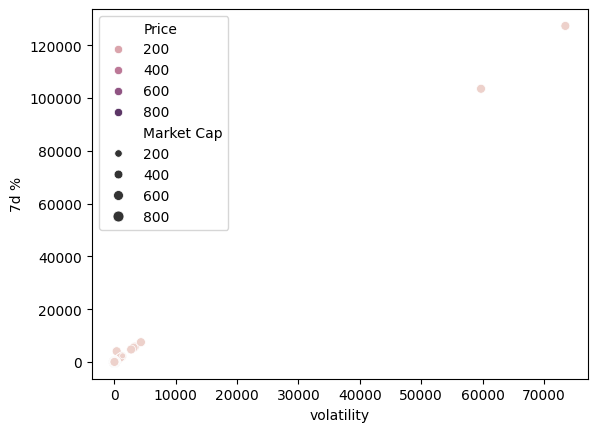

In [201]:
sns.scatterplot(data=df, x='volatility', y='7d %', size='Market Cap', hue='Price')